In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [14]:
print("Memuat dataset pertama dan kedua...")

df1 = pd.read_csv("../../data/komdigi_hoaks.csv")
df2 = pd.read_csv("../../data/datasetUMPOHoax.csv")

print("Dataset Komdigi :", df1.shape)
print("Dataset UMPO    :", df2.shape)

Memuat dataset pertama dan kedua...
Dataset Komdigi : (4176, 13)
Dataset UMPO    : (4617, 6)


In [15]:
# Langkah 3 — Menyeragamkan Kolom Teks
# Dataset Komdigi
df1['teks_gabungan'] = (
    df1['title'].fillna('') + " " +
    df1['excerpt'].fillna('')
)

df1_bersih = df1[['teks_gabungan']].copy()
df1_bersih['sumber'] = 'Komdigi'


# Dataset UMPO
df2_bersih = df2[['tweet']].copy()

df2_bersih = df2_bersih.rename(
    columns={'tweet': 'teks_gabungan'}
)

df2_bersih['sumber'] = 'UMPO'

print("Kolom dataset Komdigi:")
print(df1_bersih.head())

print("\nKolom dataset UMPO:")
print(df2_bersih.head())

Kolom dataset Komdigi:
                                       teks_gabungan   sumber
0  [HOAKS] Tautan Pencairan BSU September 2026 Se...  Komdigi
1  [HOAKS] Panas El Nino Berkaitan dengan Gelomba...  Komdigi
2  [HOAKS] Susu Bebelac Berbahaya karena Mengandu...  Komdigi
3  [HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...  Komdigi
4  [HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...  Komdigi

Kolom dataset UMPO:
                                       teks_gabungan sumber
0  Mahasiswa ITS buat pembangkit listrik dari kol...   UMPO
1  Lampu Dengan Sumber Energi Air Garam Ini Berpo...   UMPO
2  #didUknow Lampu LED yang menggunakan air dan g...   UMPO
3  #tekno Lampu Dengan Sumber Energi Air Garam In...   UMPO
4  Green House,lampu darurat dg sumber energi gar...   UMPO


In [16]:
# Langkah 4 — Membersihkan Data Kosong
# Menghapus teks kosong dari dataset Komdigi
df1_bersih = df1_bersih[
    df1_bersih['teks_gabungan'].str.strip() != ''
]

# Menghapus data kosong dari dataset UMPO
df2_bersih = df2_bersih.dropna(
    subset=['teks_gabungan']
)

# Menggabungkan kedua dataset
df_gabungan = pd.concat(
    [df1_bersih, df2_bersih],
    ignore_index=True
)

print(f"Total data siap diproses: {len(df_gabungan)} baris")

print("\nJumlah data berdasarkan sumber:")
print(df_gabungan['sumber'].value_counts())

Total data siap diproses: 8775 baris

Jumlah data berdasarkan sumber:
sumber
UMPO       4599
Komdigi    4176
Name: count, dtype: int64


In [17]:
# Langkah 5 — Vektorisasi TF-IDF
print("Menjalankan vektorisasi TF-IDF...")

tfidf = TfidfVectorizer(
    max_features=1500,
    stop_words='english'
)

X = tfidf.fit_transform(
    df_gabungan['teks_gabungan']
).toarray()

print("Ukuran matriks TF-IDF:", X.shape)

Menjalankan vektorisasi TF-IDF...
Ukuran matriks TF-IDF: (8775, 1500)


In [18]:
k = 4

print(f"Jumlah cluster yang digunakan: {k}")

Jumlah cluster yang digunakan: 4


In [19]:
print(f"Melatih model K-Means dengan K={k}...")

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df_gabungan['cluster'] = kmeans.fit_predict(X)

print("K-Means selesai.")

Melatih model K-Means dengan K=4...
K-Means selesai.


In [20]:
print("Jumlah data pada setiap cluster:")

jumlah_cluster = (
    df_gabungan['cluster']
    .value_counts()
    .sort_index()
)

print(jumlah_cluster)

Jumlah data pada setiap cluster:
cluster
0    3046
1     556
2    4581
3     592
Name: count, dtype: int64


In [21]:
print("Mereduksi dimensi data untuk visualisasi 2D...")

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

df_gabungan['pca_x'] = X_pca[:, 0]
df_gabungan['pca_y'] = X_pca[:, 1]

print("PCA selesai.")

Mereduksi dimensi data untuk visualisasi 2D...
PCA selesai.


Membuat grafik clustering...


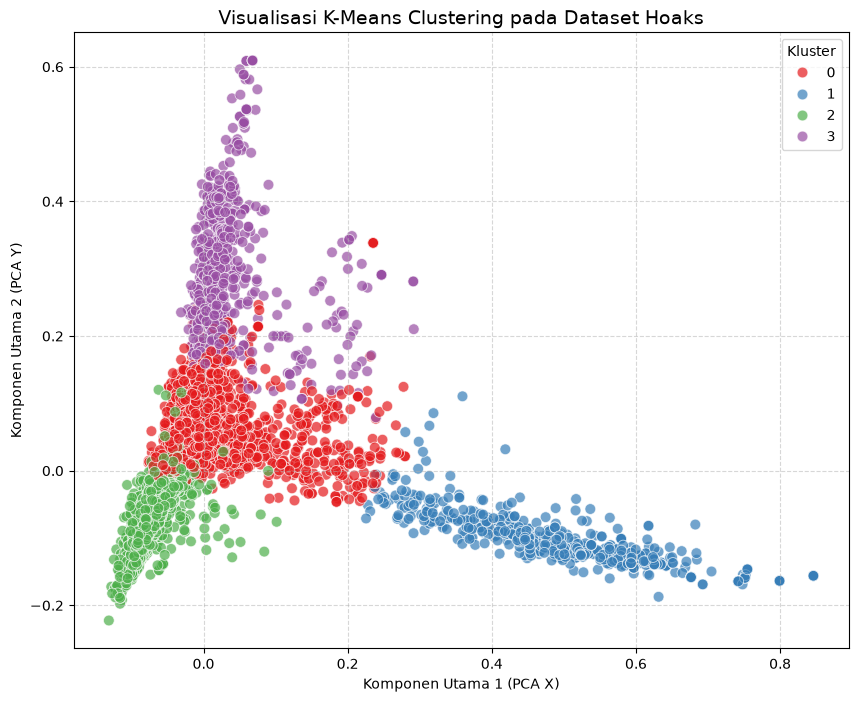

In [22]:
print("Membuat grafik clustering...")

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='pca_x',
    y='pca_y',
    hue='cluster',
    palette='Set1',
    data=df_gabungan,
    s=60,
    alpha=0.7,
    edgecolor='w'
)

plt.title(
    'Visualisasi K-Means Clustering pada Dataset Hoaks',
    fontsize=14
)

plt.xlabel('Komponen Utama 1 (PCA X)')
plt.ylabel('Komponen Utama 2 (PCA Y)')

plt.legend(
    title='Kluster',
    loc='best'
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.savefig(
    'hasil_clustering_2d.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [23]:
order_centroids = (
    kmeans.cluster_centers_
    .argsort()[:, ::-1]
)

terms = tfidf.get_feature_names_out()

print("\nHasil Kata Kunci Dominan per Kluster:")

for i in range(k):

    top_terms = [
        terms[ind]
        for ind in order_centroids[i, :7]
    ]

    print(
        f"Kluster {i}: {', '.join(top_terms)}"
    )


Hasil Kata Kunci Dominan per Kluster:
Kluster 0: hoaks, video, di, indonesia, presiden, prabowo, dan
Kluster 1: akun, mengatasnamakan, whatsapp, hoaks, kabupaten, bupati, kepala
Kluster 2: http, dan, bisa, di, yang, ini, untuk
Kluster 3: tautan, pendaftaran, lowongan, hoaks, kerja, pt, 2026


In [24]:
print("\n--- Contoh Teks Hasil Kluster ---")

for i in range(k):

    print(f"\nContoh Teks Kluster {i}:")

    contoh_teks = (
        df_gabungan[
            df_gabungan['cluster'] == i
        ]['teks_gabungan']
        .head(2)
        .tolist()
    )

    for teks in contoh_teks:
        print(f"- {teks}")


--- Contoh Teks Hasil Kluster ---

Contoh Teks Kluster 0:
- [HOAKS] Tautan Pencairan BSU September 2026 Sebesar Rp600.000 Kepala Biro Humas Kementerian Ketenagakerjaan (Kemnaker) Faried Abdurrahman Nur Yuliono mengatakan belum ada kebijakan terkait penyaluran BSU pada 2026.
- [HOAKS] Panas El Nino Berkaitan dengan Gelombang Frekuensi HAARP El Nino merupakan fenomena alam yang terjadi akibat perubahan pola sirkulasi atmosfer dan laut, termasuk melemahnya angin pasat yang menyebabkan air hangat menumpuk di wilayah timur Pasifik tropis.

Contoh Teks Kluster 1:
- [HOAKS] Akun WhatsApp Mengatasnamakan Bupati Aceh Timur Iskandar Usman Al-Farlaky 
- [HOAKS] Akun Instagram Mengatasnamakan Pejabat Kejaksaan Negeri Bengkulu Saiful Bahri Siregar 

Contoh Teks Kluster 2:
- [HOAKS] Susu Bebelac Berbahaya karena Mengandung Maltodekstrin Maltodekstrin merupakan bahan tambahan pangan (BTP) yang dinilai aman dan tidak hanya digunakan dalam susu formula.
- [HOAKS] Vaksin Covid-19 Picu Depopulasi dan Pe

Berdasarkan proses yang dilakukan, K-Means dapat digunakan untuk mengelompokkan teks hoaks dari dataset Komdigi dan UMPO berdasarkan kemiripan karakteristik kata menggunakan TF-IDF. Dengan menentukan K=4, data berhasil dibagi menjadi empat cluster yang memiliki karakteristik kosakata berbeda.

Hasil analisis kata kunci menunjukkan adanya kelompok yang cenderung berkaitan dengan isu nasional dan pemerintahan, lowongan kerja dan pendaftaran, teks media sosial dengan URL, serta pengatasnamaan akun atau identitas.

Namun, hasil tersebut merupakan interpretasi terhadap pola yang ditemukan oleh algoritma, bukan label yang diberikan secara langsung oleh K-Means. Oleh karena itu, kata kunci perlu dibandingkan dengan contoh teks dari setiap cluster untuk memastikan bahwa interpretasi tersebut sesuai dengan isi data.

Visualisasi PCA juga membantu melihat persebaran dan pemisahan antar-cluster. Akan tetapi, karena PCA hanya mereduksi data berdimensi tinggi menjadi dua dimensi, visualisasi tersebut sebaiknya digunakan sebagai pendukung analisis, bukan sebagai satu-satunya ukuran keberhasilan clustering.

Secara keseluruhan, hasil K-Means menunjukkan bahwa pendekatan TF-IDF + K-Means mampu menemukan beberapa pola kemiripan dalam kumpulan teks hoaks, tetapi kualitas cluster tetap dipengaruhi oleh pemilihan jumlah cluster (K), preprocessing teks, serta karakteristik kosakata yang terdapat pada dataset.